In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='darkgrid', palette='husl')
plt.rcParams['figure.dpi'] = 120

print("✅ Libraries ready")

✅ Libraries ready


In [2]:
users        = pd.read_csv('../data/raw/users.csv')
courses      = pd.read_csv('../data/raw/courses.csv')
transactions = pd.read_csv('../data/raw/transactions.csv')

print(f"Users shape        : {users.shape}")
print(f"Courses shape      : {courses.shape}")
print(f"Transactions shape : {transactions.shape}")

Users shape        : (2000, 3)
Courses shape      : (400, 5)
Transactions shape : (23141, 4)


In [3]:
print("══════ USERS ══════")
display(users.head(5))
display(users.dtypes)

print("══════ COURSES ══════")
display(courses.head(5))
display(courses.dtypes)

print("══════ TRANSACTIONS ══════")
display(transactions.head(5))
display(transactions.dtypes)

══════ USERS ══════


,UserID,Age,Gender
0,U0001,56,Female
1,U0002,46,Male
2,U0003,32,Male
3,U0004,60,Female
4,U0005,25,Male


UserID      str
Age       int64
Gender      str
dtype: object

══════ COURSES ══════


,CourseID,CourseCategory,CourseType,CourseLevel,CourseRating
0,C0001,Technology,Live,Intermediate,3.3
1,C0002,Technology,Self-Paced,Advanced,3.4
2,C0003,Business,Video,Intermediate,3.9
3,C0004,Data Science,Video,Intermediate,3.6
4,C0005,Business,Hybrid,Beginner,4.1


CourseID              str
CourseCategory        str
CourseType            str
CourseLevel           str
CourseRating      float64
dtype: object

══════ TRANSACTIONS ══════


,UserID,CourseID,TransactionDate,Amount
0,U0001,C0131,2022-12-10,249.64
1,U0001,C0190,2025-07-26,132.82
2,U0001,C0073,2025-09-20,36.81
3,U0001,C0290,2025-07-12,240.08
4,U0001,C0015,2024-07-08,119.68


UserID                 str
CourseID               str
TransactionDate        str
Amount             float64
dtype: object

In [4]:
transactions['TransactionDate'] = pd.to_datetime(transactions['TransactionDate'])

print("Date range:")
print(f"  From : {transactions['TransactionDate'].min()}")
print(f"  To   : {transactions['TransactionDate'].max()}")
print(f"  Span : {(transactions['TransactionDate'].max() - transactions['TransactionDate'].min()).days} days")

Date range:
  From : 2022-01-01 00:00:00
  To   : 2025-12-30 00:00:00
  Span : 1459 days


In [5]:
print("══ NULL VALUES ══")
print("Users:")
print(users.isnull().sum())
print("\nCourses:")
print(courses.isnull().sum())
print("\nTransactions:")
print(transactions.isnull().sum())

print("\n══ DUPLICATES ══")
print(f"Users        : {users.duplicated().sum()}")
print(f"Courses      : {courses.duplicated().sum()}")
print(f"Transactions : {transactions.duplicated().sum()}")

print("\n══ UNIQUE COUNTS ══")
print(f"Unique Users   : {transactions['UserID'].nunique()}")
print(f"Unique Courses : {transactions['CourseID'].nunique()}")

══ NULL VALUES ══
Users:
UserID    0
Age       0
Gender    0
dtype: int64

Courses:
CourseID          0
CourseCategory    0
CourseType        0
CourseLevel       0
CourseRating      0
dtype: int64

Transactions:
UserID             0
CourseID           0
TransactionDate    0
Amount             0
dtype: int64

══ DUPLICATES ══
Users        : 0
Courses      : 0
Transactions : 0

══ UNIQUE COUNTS ══
Unique Users   : 2000
Unique Courses : 400


In [6]:
total_revenue    = transactions['Amount'].sum()
avg_spend_user   = transactions.groupby('UserID')['Amount'].sum().mean()
avg_courses_user = transactions.groupby('UserID')['CourseID'].count().mean()
top_category     = (transactions
                    .merge(courses[['CourseID','CourseCategory']], on='CourseID')
                    ['CourseCategory'].value_counts().index[0])

print("══ KEY BUSINESS NUMBERS ══")
print(f"Total Revenue         : ${total_revenue:,.2f}")
print(f"Avg Spend per User    : ${avg_spend_user:,.2f}")
print(f"Avg Courses per User  : {avg_courses_user:.1f}")
print(f"Most Popular Category : {top_category}")
print(f"Date Range            : {transactions['TransactionDate'].min().date()} → {transactions['TransactionDate'].max().date()}")

══ KEY BUSINESS NUMBERS ══
Total Revenue         : $3,825,313.75
Avg Spend per User    : $1,912.66
Avg Courses per User  : 11.6
Most Popular Category : Technology
Date Range            : 2022-01-01 → 2025-12-30


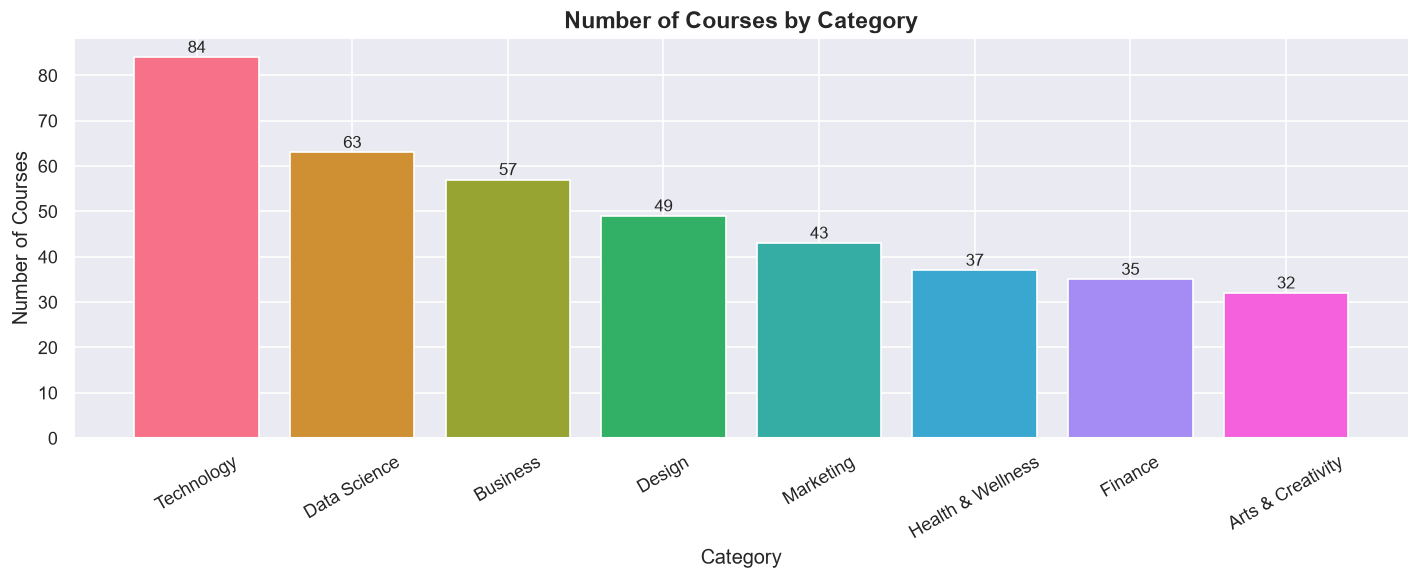

Saved ✅


In [7]:
fig, ax = plt.subplots(figsize=(12, 5))

cat_counts = courses['CourseCategory'].value_counts()
bars = ax.bar(cat_counts.index, cat_counts.values,
              color=sns.color_palette('husl', len(cat_counts)))

ax.set_title('Number of Courses by Category', fontsize=14, fontweight='bold')
ax.set_xlabel('Category')
ax.set_ylabel('Number of Courses')
ax.tick_params(axis='x', rotation=30)

for bar, val in zip(bars, cat_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 1, str(val),
            ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('../reports/figures/01_category_distribution.png', dpi=150)
plt.show()
print("Saved ✅")

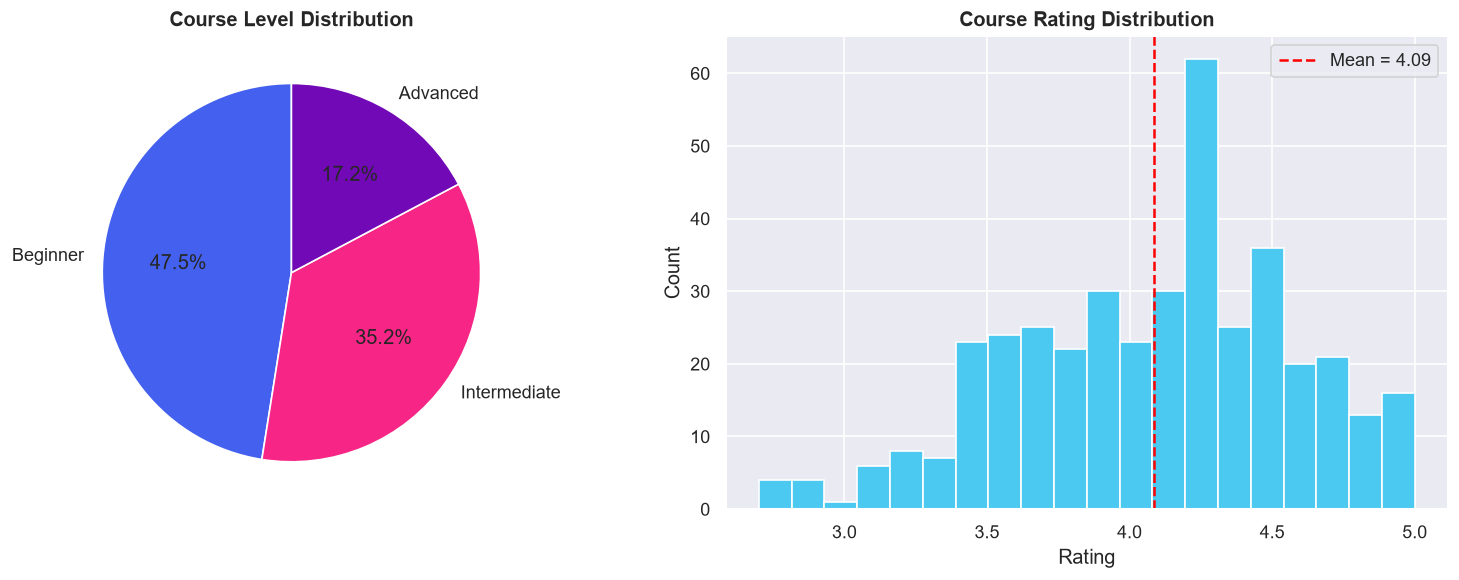

Saved ✅


In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Level pie
level_counts = courses['CourseLevel'].value_counts()
ax1.pie(level_counts, labels=level_counts.index,
        autopct='%1.1f%%', colors=['#4361ee','#f72585','#7209b7'],
        startangle=90)
ax1.set_title('Course Level Distribution', fontweight='bold')

# Rating histogram
ax2.hist(courses['CourseRating'], bins=20,
         color='#4cc9f0', edgecolor='white')
ax2.axvline(courses['CourseRating'].mean(),
            color='red', linestyle='--',
            label=f"Mean = {courses['CourseRating'].mean():.2f}")
ax2.set_title('Course Rating Distribution', fontweight='bold')
ax2.set_xlabel('Rating')
ax2.set_ylabel('Count')
ax2.legend()

plt.tight_layout()
plt.savefig('../reports/figures/02_level_rating.png', dpi=150)
plt.show()
print("Saved ✅")

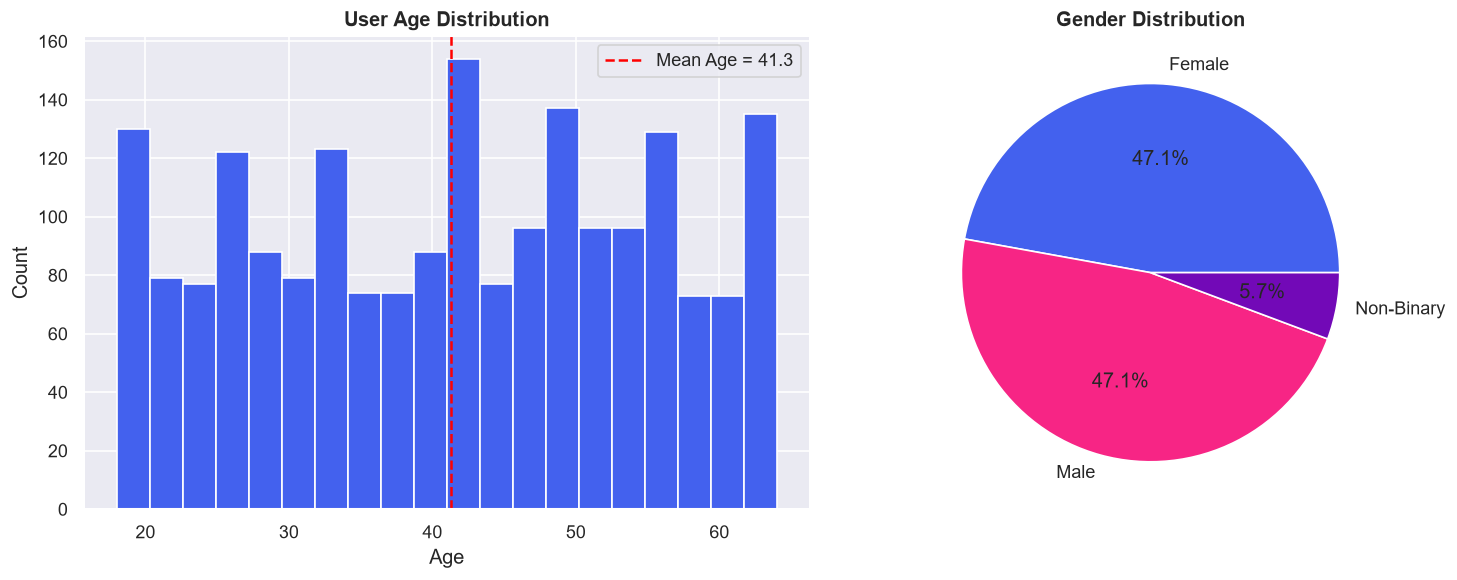

Saved ✅


In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Age histogram
ax1.hist(users['Age'], bins=20,
         color='#4361ee', edgecolor='white')
ax1.set_title('User Age Distribution', fontweight='bold')
ax1.set_xlabel('Age')
ax1.set_ylabel('Count')
ax1.axvline(users['Age'].mean(), color='red',
            linestyle='--',
            label=f"Mean Age = {users['Age'].mean():.1f}")
ax1.legend()

# Gender pie
gender_counts = users['Gender'].value_counts()
ax2.pie(gender_counts, labels=gender_counts.index,
        autopct='%1.1f%%',
        colors=['#4361ee','#f72585','#7209b7'])
ax2.set_title('Gender Distribution', fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/figures/03_user_demographics.png', dpi=150)
plt.show()
print("Saved ✅")

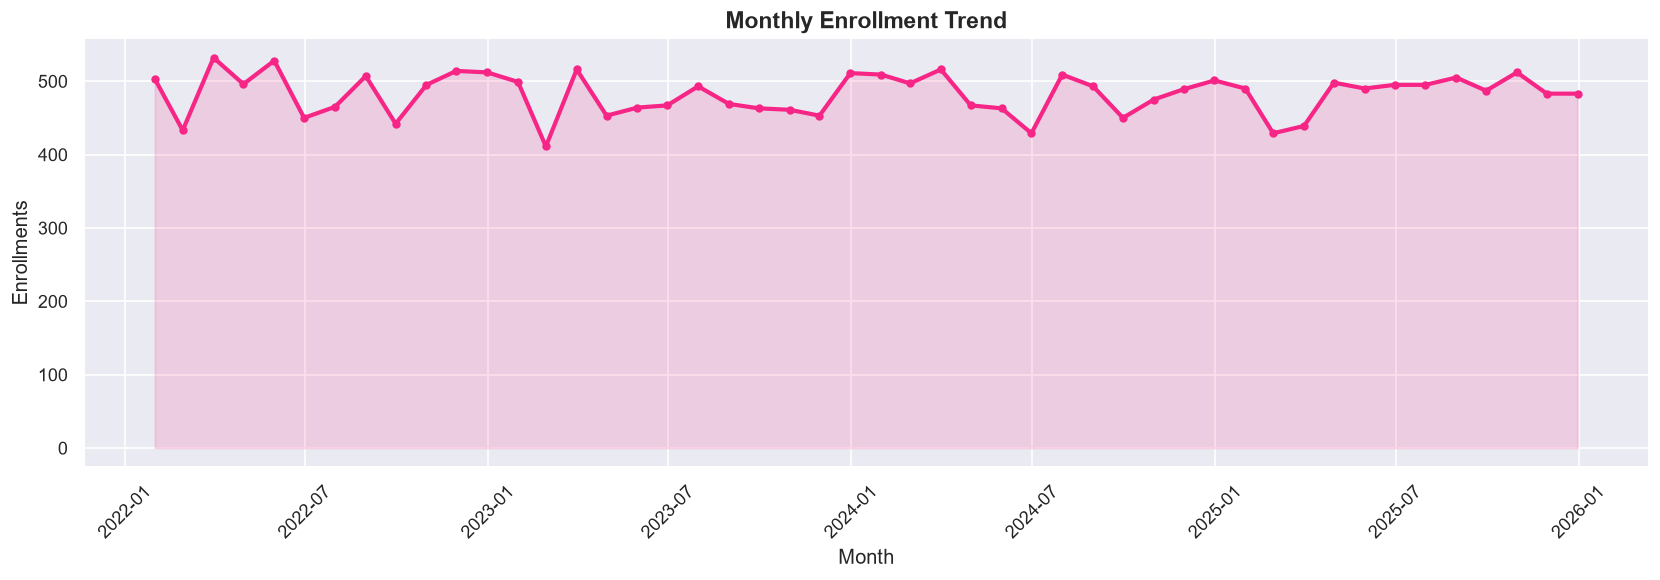

Saved ✅


In [10]:
transactions['TransactionDate'] = pd.to_datetime(transactions['TransactionDate'])

monthly = (transactions
           .set_index('TransactionDate')
           .resample('ME')['CourseID']   # ← changed 'M' to 'ME'
           .count()
           .reset_index())
monthly.columns = ['Month', 'Enrollments']

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly['Month'], monthly['Enrollments'],
        color='#f72585', linewidth=2.5, marker='o', markersize=4)
ax.fill_between(monthly['Month'], monthly['Enrollments'],
                alpha=0.15, color='#f72585')
ax.set_title('Monthly Enrollment Trend', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Enrollments')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../reports/figures/04_enrollment_trend.png', dpi=150)
plt.show()
print("Saved ✅")

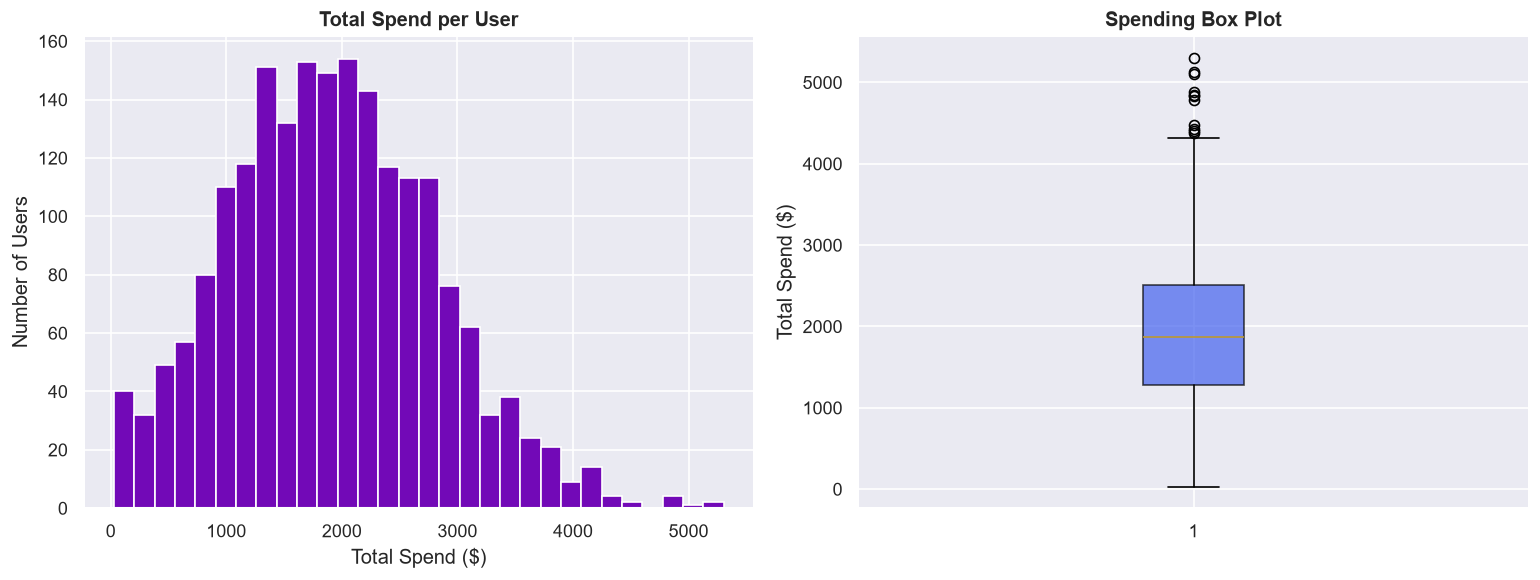

Saved ✅


In [11]:
user_spend = (transactions
              .groupby('UserID')['Amount']
              .sum()
              .reset_index(name='TotalSpend'))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.hist(user_spend['TotalSpend'], bins=30,
         color='#7209b7', edgecolor='white')
ax1.set_title('Total Spend per User', fontweight='bold')
ax1.set_xlabel('Total Spend ($)')
ax1.set_ylabel('Number of Users')

ax2.boxplot(user_spend['TotalSpend'],
            patch_artist=True,
            boxprops=dict(facecolor='#4361ee', alpha=0.7))
ax2.set_title('Spending Box Plot', fontweight='bold')
ax2.set_ylabel('Total Spend ($)')

plt.tight_layout()
plt.savefig('../reports/figures/05_spending_distribution.png', dpi=150)
plt.show()
print("Saved ✅")

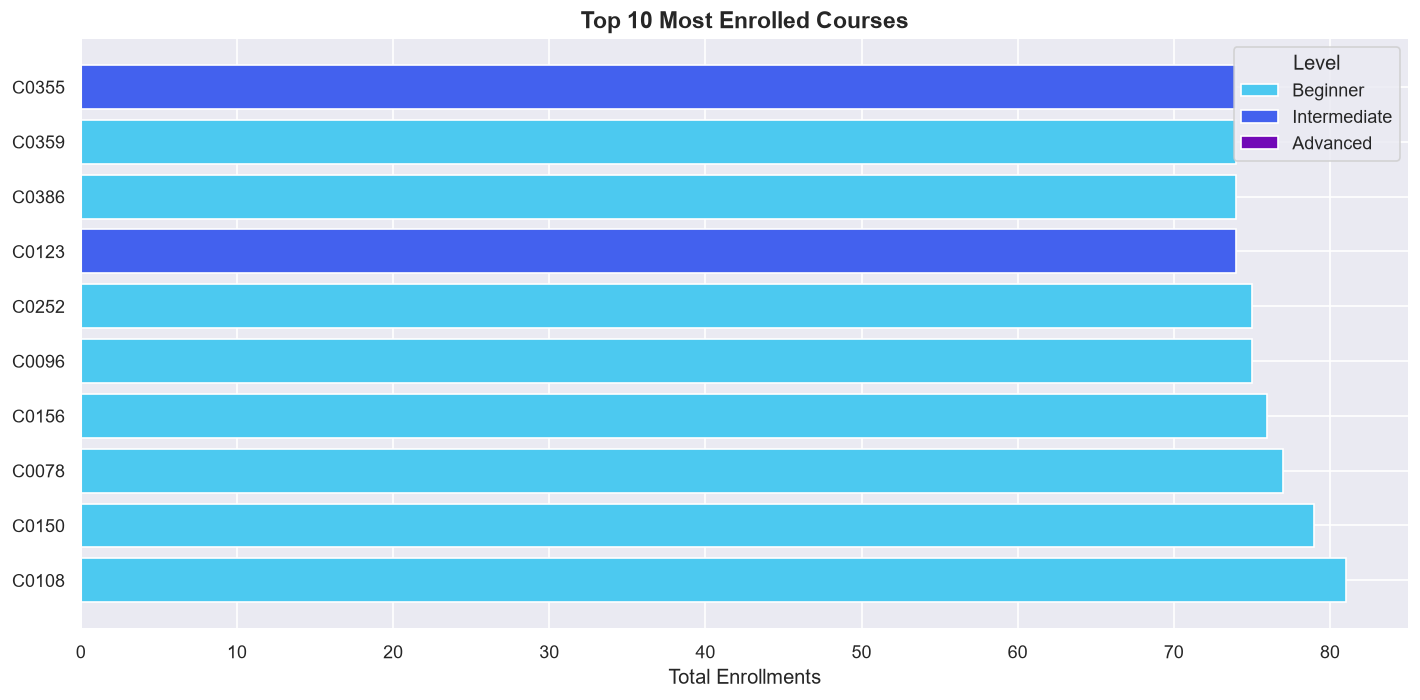

Saved ✅


In [12]:
top_courses = (transactions
               .merge(courses[['CourseID','CourseCategory','CourseLevel']], on='CourseID')
               .groupby(['CourseID','CourseCategory','CourseLevel'])
               .size()
               .reset_index(name='Enrollments')
               .sort_values('Enrollments', ascending=False)
               .head(10))

fig, ax = plt.subplots(figsize=(12, 6))
colors_map = {'Beginner':'#4cc9f0','Intermediate':'#4361ee','Advanced':'#7209b7'}
bar_colors = [colors_map[l] for l in top_courses['CourseLevel']]
bars = ax.barh(top_courses['CourseID'], top_courses['Enrollments'], color=bar_colors)
ax.set_title('Top 10 Most Enrolled Courses', fontsize=14, fontweight='bold')
ax.set_xlabel('Total Enrollments')
from matplotlib.patches import Patch
legend = [Patch(facecolor=v, label=k) for k, v in colors_map.items()]
ax.legend(handles=legend, title='Level')
plt.tight_layout()
plt.savefig('../reports/figures/06_top_courses.png', dpi=150)
plt.show()
print("Saved ✅")

In [13]:
print("═══════════════════════════════════")
print("   DAY 1 COMPLETE — EDA SUMMARY")
print("═══════════════════════════════════")
print(f"Total Users        : {len(users):,}")
print(f"Total Courses      : {len(courses):,}")
print(f"Total Transactions : {len(transactions):,}")
print(f"Total Revenue      : ${transactions['Amount'].sum():,.2f}")
print(f"Avg Spend/User     : ${transactions.groupby('UserID')['Amount'].sum().mean():,.2f}")
print(f"Avg Courses/User   : {transactions.groupby('UserID')['CourseID'].count().mean():.1f}")
print(f"Date Range         : {transactions['TransactionDate'].min().date()} → {transactions['TransactionDate'].max().date()}")
print(f"Top Category       : {transactions.merge(courses[['CourseID','CourseCategory']], on='CourseID')['CourseCategory'].value_counts().index[0]}")
print(f"Avg Course Rating  : {courses['CourseRating'].mean():.2f}")
print("═══════════════════════════════════")
print("Charts saved to reports/figures/ ✅")
print("Ready for Day 2 — Feature Engineering")

═══════════════════════════════════
   DAY 1 COMPLETE — EDA SUMMARY
═══════════════════════════════════
Total Users        : 2,000
Total Courses      : 400
Total Transactions : 23,141
Total Revenue      : $3,825,313.75
Avg Spend/User     : $1,912.66
Avg Courses/User   : 11.6
Date Range         : 2022-01-01 → 2025-12-30
Top Category       : Technology
Avg Course Rating  : 4.09
═══════════════════════════════════
Charts saved to reports/figures/ ✅
Ready for Day 2 — Feature Engineering
